<a href="https://colab.research.google.com/github/SLCFLAB/Fintech2026-2/blob/main/DL09_generative_models/GEN_2_GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 생성모델 2. GAN (Generative Adversarial Network)


| 순서 | 내용 |
|---|---|
| 1 | GAN 원리 |
| 2 | 2D toy 데이터로 G와 D의 작동방식 시각화 |
| 3 | MNIST GAN 학습 |
| 4 | 생성 결과 평가: mode coverage, memorization 체크 |
| 5 | WGAN-GP |

- 전체 실행 시간: T4 GPU 기준 약 8~10분

Reference: https://github.com/eriklindernoren/PyTorch-GAN

## 1. GAN 원리

- **Generator (G)**: 랜덤 noise $z \sim N(0, I)$ → 가짜 데이터 $G(z)$ 생성. *위조지폐범*
- **Discriminator (D)**: 입력이 진짜일 확률 $D(x)$ 출력. *경찰*
- D는 진짜/가짜를 잘 구분하도록, G는 D를 속이도록 **번갈아** 학습함

$$\min_G \max_D \; \mathbb{E}_{x\sim p_{data}}[\log D(x)] + \mathbb{E}_{z}[\log(1 - D(G(z)))]$$

실제 구현은 이진 분류 BCE loss 두 개:

| 학습 대상 | 입력 | 목표 label | 의미 |
|---|---|---|---|
| D | 진짜 이미지 | 1 | 진짜는 진짜라고 |
| D | 가짜 이미지 `G(z).detach()` | 0 | 가짜는 가짜라고 |
| G | 가짜 이미지 `G(z)` | **1** | D가 가짜를 진짜라고 믿게 |

> VAE와 달리 **likelihood나 재구성 오차를 직접 계산하지 않음**. "진짜 같음"의 기준 자체를 D가 학습함 → 선명한 이미지가 나오지만 학습이 불안정함.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.datasets as dsets
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
print("device:", DEVICE)

def show_grid(imgs, nrow=8, title=None, ax=None):
    # imgs: [N, 1, 28, 28], 값 범위 [-1, 1] → [0, 1]로 되돌려서 그림
    grid = make_grid(imgs.detach().cpu() * 0.5 + 0.5, nrow=nrow, padding=2, pad_value=1)
    ax = ax or plt.figure(figsize=(nrow * 0.8, len(imgs) // nrow * 0.8)).gca()
    ax.imshow(grid.permute(1, 2, 0).clamp(0, 1)); ax.axis("off")
    if title: ax.set_title(title)

device: cuda


## 2. 2D toy 데이터: G와 D의 작동방식

이미지는 784차원이라 분포를 눈으로 볼 수 없음. **2차원 데이터**(원 위의 8개 점 뭉치)로 먼저 원리를 확인함.

- 회색 점: 진짜 데이터, 빨간 점: G가 만든 가짜
- 배경색: D(x) 값 (진한 초록 = D가 "진짜"라고 판단하는 영역)

In [2]:
def sample_real_2d(n):
    # 원 위 8개 중심 중 하나를 고르고 작은 noise 추가 → 8개 mode를 가진 분포
    angle = torch.randint(0, 8, (n,)).float() * 2 * np.pi / 8
    centers = torch.stack([torch.cos(angle), torch.sin(angle)], dim=1) * 2
    return centers + 0.05 * torch.randn(n, 2)

def mlp(d_in, d_out, h=128):
    return nn.Sequential(nn.Linear(d_in, h), nn.ReLU(), nn.Linear(h, h), nn.ReLU(),
                         nn.Linear(h, h), nn.ReLU(), nn.Linear(h, d_out))

G2 = mlp(2, 2).to(DEVICE)     # z(2차원) → x(2차원)
D2 = mlp(2, 1).to(DEVICE)     # x(2차원) → logit 1개 (sigmoid는 loss에 포함)
opt_G2 = torch.optim.Adam(G2.parameters(), lr=1e-3, betas=(0.5, 0.999))   # GAN에선 beta1=0.5가 관례
opt_D2 = torch.optim.Adam(D2.parameters(), lr=1e-3, betas=(0.5, 0.999))
bce = nn.BCEWithLogitsLoss()  # sigmoid + BCE를 합친 버전 (수치적으로 더 안정)

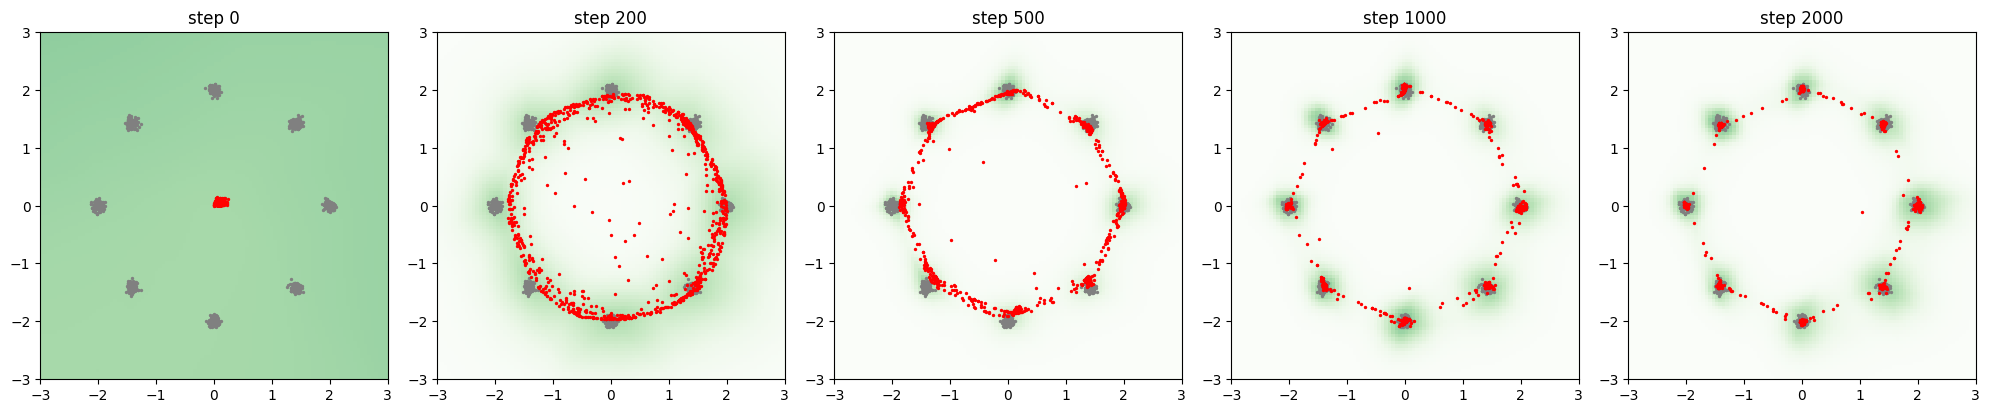

In [3]:
B = 256
ones, zeros = torch.ones(B, 1, device=DEVICE), torch.zeros(B, 1, device=DEVICE)
z_fixed = torch.randn(1000, 2, device=DEVICE)             # 진행 상황 비교용 고정 noise
snapshots = {}

for step in range(2001):
    real = sample_real_2d(B).to(DEVICE)
    z = torch.randn(B, 2, device=DEVICE)
    fake = G2(z)

    # --- (1) D 학습: 진짜 → 1, 가짜 → 0
    # fake.detach(): D를 학습할 땐 G까지 gradient가 흐르지 않게 끊음
    loss_D = bce(D2(real), ones) + bce(D2(fake.detach()), zeros)
    opt_D2.zero_grad(); loss_D.backward(); opt_D2.step()

    # --- (2) G 학습: D가 가짜를 1(진짜)로 판단하도록
    # log(1 - D(G(z)))를 최소화하는 대신 -log D(G(z))를 최소화 (non-saturating loss: 초반 gradient 소실 방지)
    loss_G = bce(D2(fake), ones)
    opt_G2.zero_grad(); loss_G.backward(); opt_G2.step()

    if step in [0, 200, 500, 1000, 2000]:
        with torch.no_grad():
            snapshots[step] = G2(z_fixed).cpu()
            gx, gy = torch.meshgrid(torch.linspace(-3, 3, 100), torch.linspace(-3, 3, 100), indexing="xy")
            d_map = torch.sigmoid(D2(torch.stack([gx, gy], -1).view(-1, 2).to(DEVICE))).view(100, 100).cpu()
            snapshots[step] = (snapshots[step], d_map)

real_vis = sample_real_2d(1000)
fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 4))
for ax, (step, (fake_vis, d_map)) in zip(axes, snapshots.items()):
    ax.imshow(d_map, extent=(-3, 3, -3, 3), origin="lower", cmap="Greens", vmin=0, vmax=1, alpha=0.6)
    ax.scatter(real_vis[:, 0], real_vis[:, 1], s=2, c="gray")
    ax.scatter(fake_vis[:, 0], fake_vis[:, 1], s=2, c="red")
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_title(f"step {step}")
plt.tight_layout(); plt.show()

- 초반: G는 한 점 근처만 출력 → D는 "그 점만 아니면 진짜"라고 판단 → G가 초록 영역으로 이동
- D의 판단 지형(배경)이 G에게 **어디로 가야 하는지 알려주는 gradient** 역할을 함
- 학습 후반에도 mode 사이에 **다리처럼 이어진 점들** 이 남음: G는 연속 함수라서 연속적인 z 공간을 끊어진 8개 뭉치로 완벽히 나누기 어려움
- `torch.manual_seed` 를 바꿔 여러 번 돌려보면 결과가 매번 다름 → GAN 학습의 **불안정성**. 설정에 따라 일부 mode만 생성하는 **mode collapse** 도 발생함

## 3. MNIST GAN (DCGAN 구조)

- CNN 수업 내용을 이어서 **conv 기반 DCGAN** 으로 구현 → parameter는 더 적고, 더 빨리 선명해짐
- **D** = 평범한 CNN 분류기 (진짜/가짜 이진 분류)
- **G** = D를 거꾸로 뒤집은 구조. `ConvTranspose2d(stride=2)` 로 해상도를 **2배씩 키움** (7 → 14 → 28)
  - 출력 크기 공식: $(N-1)\times S - 2P + F$ → $(7-1)\times2 - 2 + 4 = 14$
- G 마지막 `Tanh` → 출력 범위 [-1, 1]. 그래서 **진짜 이미지도 `Normalize(0.5, 0.5)`로 [-1, 1]로 맞춰야 함** (범위 불일치 시 D가 쉽게 구분해버림)

In [4]:
LATENT_DIM = 100
BATCH_SIZE = 128
EPOCHS = 10            # 늘리면 품질 향상

transform = transforms.Compose([
    transforms.ToTensor(),                       # [0, 1]
    transforms.Normalize([0.5], [0.5]),          # [0, 1] → [-1, 1]  (G의 Tanh 출력 범위와 맞춤)
])
mnist = dsets.MNIST("./data", train=True, download=True, transform=transform)
loader = DataLoader(mnist, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)


class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(                                  # z → 작은 feature map
            nn.Linear(LATENT_DIM, 128 * 7 * 7), nn.BatchNorm1d(128 * 7 * 7), nn.ReLU())
        self.deconv = nn.Sequential(                              # [B, 128, 7, 7]
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),  # [B, 64, 14, 14]
            nn.BatchNorm2d(64), nn.ReLU(),                        # BatchNorm: G 학습 안정화
            nn.ConvTranspose2d(64, 1, 4, stride=2, padding=1),    # [B, 1, 28, 28]
            nn.Tanh(),                                            # 픽셀 범위 [-1, 1]
        )

    def forward(self, z):
        return self.deconv(self.fc(z).view(-1, 128, 7, 7))


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(                               # [B, 1, 28, 28]
            nn.Conv2d(1, 64, 4, stride=2, padding=1),             # [B, 64, 14, 14]  pooling 대신 stride로 축소
            nn.LeakyReLU(0.2),                                    # LeakyReLU: 음수 영역도 gradient 전달 → G가 학습 신호를 잘 받음
            nn.Conv2d(64, 128, 4, stride=2, padding=1),           # [B, 128, 7, 7]
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),                            # logit 1개 (sigmoid는 BCEWithLogitsLoss 안에 있음)
        )

    def forward(self, img):
        return self.model(img)


count_params = lambda m: sum(p.numel() for p in m.parameters())
print(f"G params: {count_params(Generator()):,} | D params: {count_params(Discriminator()):,}")
print("G output shape:", tuple(Generator()(torch.randn(2, LATENT_DIM)).shape))

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.63MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.76MB/s]


G params: 778,305 | D params: 138,561
G output shape: (2, 1, 28, 28)


In [5]:
generator, discriminator = Generator().to(DEVICE), Discriminator().to(DEVICE)
opt_G = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))
z_fixed = torch.randn(32, LATENT_DIM, device=DEVICE)     # 매 epoch 같은 z로 생성 → 변화 추적
log = {"D": [], "G": [], "D(x)": [], "D(G(z))": []}
progress = {}

for epoch in range(1, EPOCHS + 1):
    generator.train(); discriminator.train()
    for real, _ in loader:                         # label은 사용 안 함 (비지도 학습)
        real = real.to(DEVICE)
        ones  = torch.ones(real.size(0), 1, device=DEVICE)
        zeros = torch.zeros(real.size(0), 1, device=DEVICE)

        # ---------- D 학습 ----------
        z = torch.randn(real.size(0), LATENT_DIM, device=DEVICE)
        fake = generator(z)
        d_real, d_fake = discriminator(real), discriminator(fake.detach())
        loss_D = (bce(d_real, ones) + bce(d_fake, zeros)) / 2
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        # ---------- G 학습 ----------
        loss_G = bce(discriminator(fake), ones)     # D를 속이는 방향으로
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()

        log["D"].append(loss_D.item()); log["G"].append(loss_G.item())
        log["D(x)"].append(torch.sigmoid(d_real).mean().item())      # 진짜에 대한 D 확신도
        log["D(G(z))"].append(torch.sigmoid(d_fake).mean().item())   # 가짜에 대한 D 확신도

    generator.eval()
    with torch.no_grad():
        progress[epoch] = generator(z_fixed).cpu()
    print(f"epoch {epoch:2d}/{EPOCHS}  loss_D {np.mean(log['D'][-len(loader):]):.3f}  loss_G {np.mean(log['G'][-len(loader):]):.3f}")

epoch  1/10  loss_D 0.098  loss_G 5.489
epoch  2/10  loss_D 0.466  loss_G 1.301
epoch  3/10  loss_D 0.462  loss_G 1.276
epoch  4/10  loss_D 0.377  loss_G 1.452
epoch  5/10  loss_D 0.414  loss_G 1.422
epoch  6/10  loss_D 0.465  loss_G 1.313
epoch  7/10  loss_D 0.490  loss_G 1.225
epoch  8/10  loss_D 0.510  loss_G 1.174
epoch  9/10  loss_D 0.520  loss_G 1.139
epoch 10/10  loss_D 0.525  loss_G 1.129


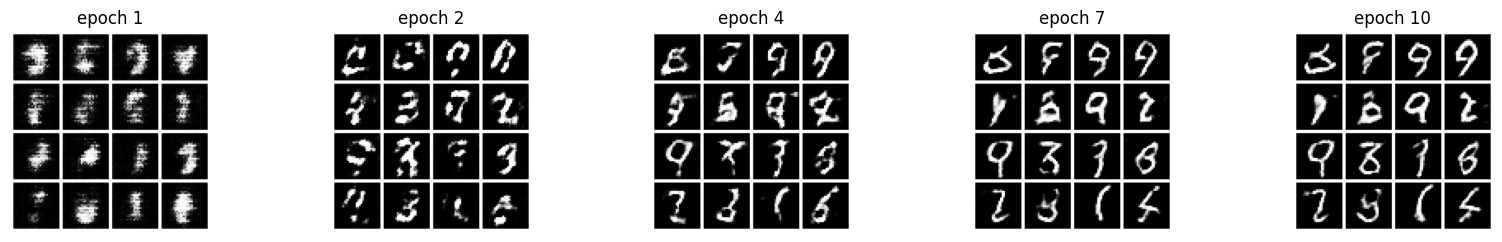

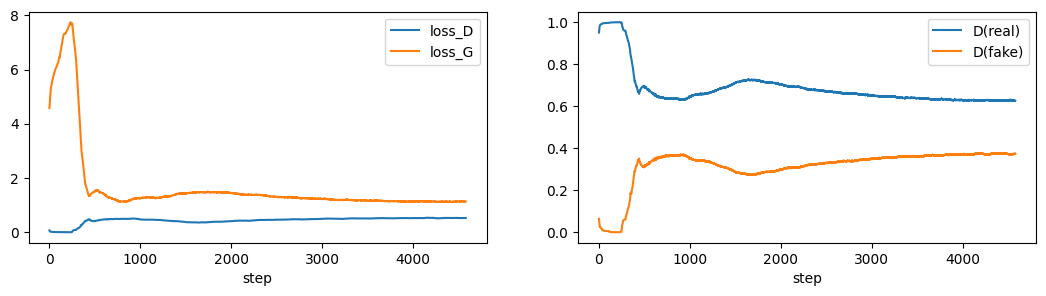

In [6]:
show_epochs = [e for e in [1, 2, 4, 7, EPOCHS] if e in progress]
fig, axes = plt.subplots(1, len(show_epochs), figsize=(4 * len(show_epochs), 2.6))
for ax, e in zip(axes, show_epochs):
    show_grid(progress[e][:16], nrow=4, title=f"epoch {e}", ax=ax)
plt.show()

smooth = lambda h: np.convolve(h, np.ones(100) / 100, mode="valid")
fig, axes = plt.subplots(1, 2, figsize=(13, 3))
axes[0].plot(smooth(log["D"]), label="loss_D"); axes[0].plot(smooth(log["G"]), label="loss_G"); axes[0].legend(); axes[0].set_xlabel("step")
axes[1].plot(smooth(log["D(x)"]), label="D(real)"); axes[1].plot(smooth(log["D(G(z))"]), label="D(fake)"); axes[1].legend(); axes[1].set_xlabel("step")
plt.show()

**GAN loss 특징**
- 일반 모델과 달리 **loss가 계속 줄지 않음**. G가 좋아지면 D loss가 오르고, D가 좋아지면 G loss가 오름
- 그래서 **loss 값으로 생성 품질을 판단할 수 없음** → 이미지를 직접 보거나, 별도의 평가 지표가 필요함 (다음 섹션)
- 위험 신호: D(real)≈1, D(fake)≈0 에 붙어버림 → D가 너무 강해서 G가 gradient를 못 받음
- 학습 초반에 잠깐 이런 구간(D 압도, loss_G 급등)이 나타났다가 회복되는 건 흔함. **계속 붙어 있으면** 실패 신호임
- 학습 잘됐나 판단: D(real)과 D(fake)가 0.5 근처에서 줄다리기

## 4. 생성 결과 평가하기

"그럴듯해 보인다"는 주관적임. 실제로 활용할 때(예: 합성 데이터 생성)는 최소한 아래 두 가지를 확인해야 함.

1. **다양성 (mode coverage)**: 모든 종류를 골고루 만드는가? 특정 숫자만 만들면 mode collapse
2. **암기 여부 (memorization)**: 학습 데이터를 그대로 복사하는 건 아닌가? (개인정보가 든 데이터라면 치명적)

### 4-1. Mode coverage: 분류기로 생성 숫자 세기
MNIST 분류기를 빠르게 하나 학습시켜서, 생성 이미지 5000장이 어떤 숫자로 분류되는지 셈. (FID, Inception Score 같은 지표도 같은 아이디어: *사전학습된 분류기로 생성물 평가*)

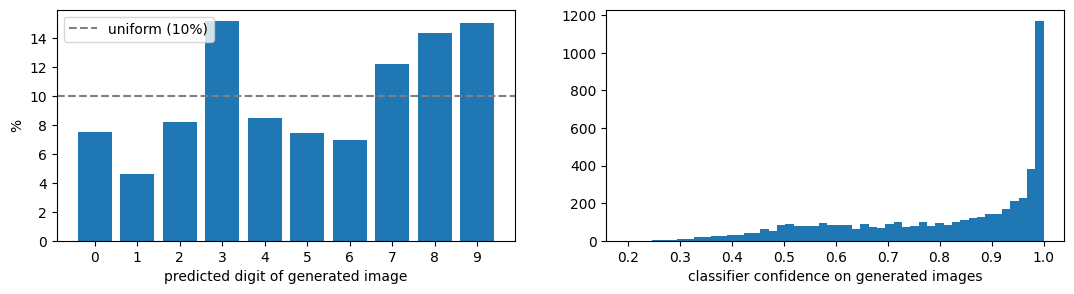

classifier confidence > 0.9 비율: 46.5%  (높을수록 '알아볼 수 있는' 숫자)


In [7]:
# 평가용 간단한 CNN 분류기 (1 epoch이면 ~98%)
clf = nn.Sequential(
    nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(), nn.Linear(64 * 7 * 7, 10),
).to(DEVICE)
opt_c = torch.optim.Adam(clf.parameters(), lr=1e-3)
for x, y in loader:
    loss = F.cross_entropy(clf(x.to(DEVICE)), y.to(DEVICE))
    opt_c.zero_grad(); loss.backward(); opt_c.step()
clf.eval()

with torch.no_grad():
    gen = generator(torch.randn(5000, LATENT_DIM, device=DEVICE))
    p = F.softmax(clf(gen), dim=1)
counts = torch.bincount(p.argmax(1), minlength=10).cpu()

fig, axes = plt.subplots(1, 2, figsize=(13, 3))
axes[0].bar(range(10), counts / 50); axes[0].axhline(10, ls="--", c="gray", label="uniform (10%)")
axes[0].set_xticks(range(10)); axes[0].set_xlabel("predicted digit of generated image"); axes[0].set_ylabel("%"); axes[0].legend()
axes[1].hist(p.max(1).values.cpu(), bins=50); axes[1].set_xlabel("classifier confidence on generated images")
plt.show()
print(f"classifier confidence > 0.9 비율: {(p.max(1).values > 0.9).float().mean()*100:.1f}%  (높을수록 '알아볼 수 있는' 숫자)")

- 10% 선에서 크게 벗어난 숫자 = G가 덜 만들거나(missing mode) 과하게 만드는 숫자
- confidence가 낮은 샘플 = 분류기도 헷갈리는 애매한 이미지 → 품질 지표로 활용 가능

### 4-2. Memorization 체크: 가장 가까운 학습 이미지 찾기
생성 이미지마다 학습 데이터 중 **픽셀 거리가 가장 가까운 이미지** 를 찾아 나란히 비교함. 거의 똑같다면 암기한 것임.

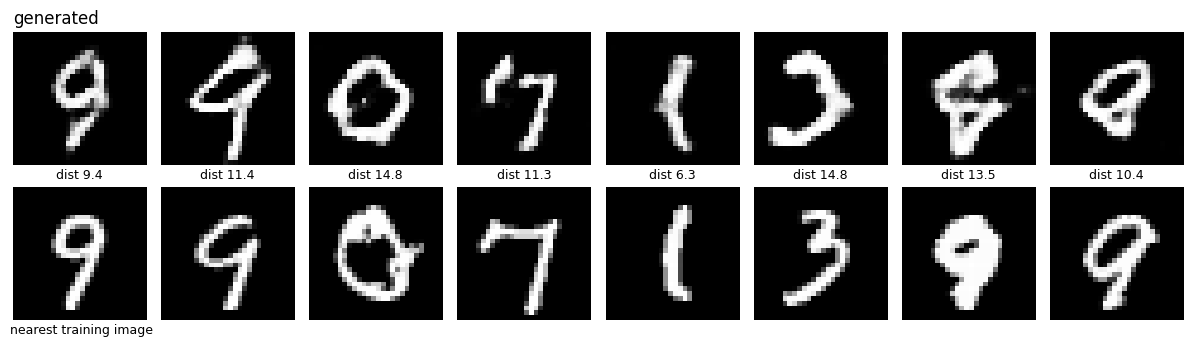

In [8]:
train_x = torch.stack([mnist[i][0] for i in range(20000)]).to(DEVICE)   # 학습 데이터 일부 (시간 절약)
samples = gen[:8]
dist = torch.cdist(samples.view(8, -1), train_x.view(len(train_x), -1))  # [8, 20000] 유클리드 거리
nn_idx = dist.argmin(1)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for i in range(8):
    axes[0, i].imshow(samples[i, 0].cpu() * 0.5 + 0.5, cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(train_x[nn_idx[i], 0].cpu() * 0.5 + 0.5, cmap="gray"); axes[1, i].axis("off")
    axes[1, i].set_title(f"dist {dist[i, nn_idx[i]]:.1f}", fontsize=9)
axes[0, 0].set_title("generated", loc="left"); fig.text(0.01, 0.02, "nearest training image", fontsize=9)
plt.tight_layout(); plt.show()

- 비슷한 스타일이지만 동일하진 않음 → 학습 데이터를 복사한 게 아니라 **분포를 학습**한 것
- 픽셀 거리는 조잡한 기준임. 실제로는 feature 공간 거리, 개인정보 관점의 공격(membership inference) 테스트까지 고려함

### 4-3. Latent space는 연속적임
두 z 사이를 선형 보간하면 이미지도 부드럽게 바뀜 → G가 z 공간을 의미 있게 구성했다는 증거

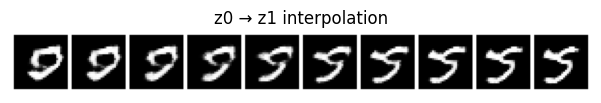

In [9]:
z0, z1 = torch.randn(2, LATENT_DIM, device=DEVICE)
alphas = torch.linspace(0, 1, 10, device=DEVICE).view(-1, 1)
with torch.no_grad():
    interp = generator((1 - alphas) * z0 + alphas * z1)
show_grid(interp, nrow=10, title="z0 → z1 interpolation"); plt.show()

## 5. (선택) WGAN-GP: 더 안정적인 GAN

원래 GAN의 문제: D가 너무 잘하면 D(G(z))≈0 → G가 받는 gradient가 사라짐 → 학습 정체.

**Wasserstein GAN** 아이디어: D를 확률(진짜일 확률) 대신 **점수(critic)** 로 바꾸고, "진짜 점수 - 가짜 점수"를 두 분포 사이 거리(Wasserstein distance) 추정치로 사용함.

| | GAN | WGAN-GP |
|---|---|---|
| D 출력 | 확률 (sigmoid) | 점수 (제한 없음), **critic** 이라 부름 |
| D loss | BCE | `D(fake).mean() - D(real).mean()` + gradient penalty |
| G loss | BCE (label 1) | `-D(fake).mean()` |
| 조건 | - | D가 1-Lipschitz (기울기 크기 ≤ 1) → **gradient penalty** 로 강제 |
| 학습 비율 | D:G = 1:1 | D를 G보다 자주 (`n_critic=5`) |
| loss 의미 | 품질과 무관 | critic loss가 **품질과 어느 정도 상관** 있음 |

> 널리 쓰이는 WGAN-GP로 구현. (G, D) 구조는 위와 동일함.

epoch 1/5  W-distance estimate 29.234
epoch 2/5  W-distance estimate 23.792
epoch 3/5  W-distance estimate 7.642
epoch 4/5  W-distance estimate 4.735
epoch 5/5  W-distance estimate 4.494


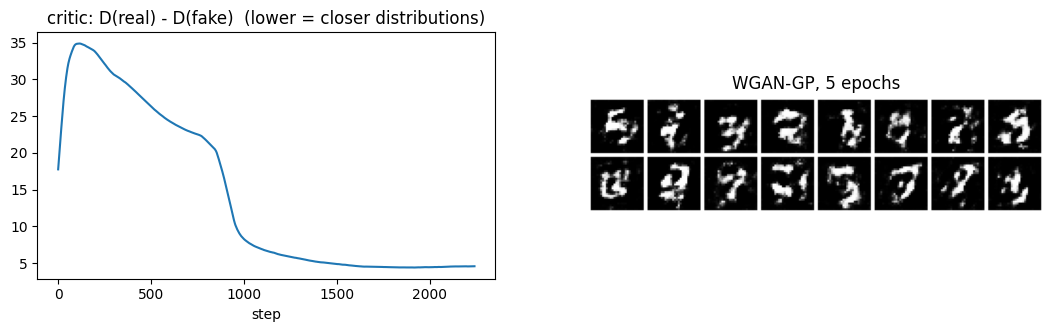

In [10]:
WGAN_EPOCHS = 5      # 시간 여유 있으면 늘리기
N_CRITIC, LAMBDA_GP = 5, 10

def gradient_penalty(D, real, fake):
    # 진짜와 가짜 사이 임의의 점에서 D의 기울기 크기가 1이 되도록 강제
    alpha = torch.rand(real.size(0), 1, 1, 1, device=DEVICE)
    x_hat = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    grad = torch.autograd.grad(D(x_hat).sum(), x_hat, create_graph=True)[0]
    return ((grad.view(grad.size(0), -1).norm(dim=1) - 1) ** 2).mean()

G_w, D_w = Generator().to(DEVICE), Discriminator().to(DEVICE)
opt_Gw = torch.optim.Adam(G_w.parameters(), lr=1e-4, betas=(0.5, 0.9))
opt_Dw = torch.optim.Adam(D_w.parameters(), lr=1e-4, betas=(0.5, 0.9))
w_dist = []

for epoch in range(1, WGAN_EPOCHS + 1):
    for i, (real, _) in enumerate(loader):
        real = real.to(DEVICE)
        fake = G_w(torch.randn(real.size(0), LATENT_DIM, device=DEVICE))

        # critic 학습: 진짜 점수는 높게, 가짜 점수는 낮게
        d_real, d_fake = D_w(real).mean(), D_w(fake.detach()).mean()
        loss_D = d_fake - d_real + LAMBDA_GP * gradient_penalty(D_w, real, fake.detach())
        opt_Dw.zero_grad(); loss_D.backward(); opt_Dw.step()
        w_dist.append((d_real - d_fake).item())         # Wasserstein distance 추정치

        if i % N_CRITIC == 0:                           # G는 critic 5번에 1번만 학습
            loss_G = -D_w(fake).mean()
            opt_Gw.zero_grad(); loss_G.backward(); opt_Gw.step()
    print(f"epoch {epoch}/{WGAN_EPOCHS}  W-distance estimate {np.mean(w_dist[-len(loader):]):.3f}")

G_w.eval()
fig, axes = plt.subplots(1, 2, figsize=(13, 3.2))
axes[0].plot(smooth(w_dist)); axes[0].set_xlabel("step"); axes[0].set_title("critic: D(real) - D(fake)  (lower = closer distributions)")
with torch.no_grad():
    show_grid(G_w(z_fixed)[:16], nrow=8, title=f"WGAN-GP, {WGAN_EPOCHS} epochs", ax=axes[1])
plt.show()

- 초반에 critic이 먼저 강해지면서 값이 치솟는 건 정상. 이후 G가 따라잡으면서 **감소하는 경향** → vanilla GAN loss와 달리 학습 모니터링에 어느 정도 활용 가능 (완벽한 품질 지표는 아님)
- G가 5 step에 1번만 업데이트되므로 같은 epoch 기준으로는 vanilla GAN보다 느리게 좋아짐

---
## Discussion
1. 원하는 숫자를 생성하려면 G와 D에 무엇을 추가로 넣어줘야 할까? (Conditional GAN)
   - 숫자 label(one-hot 또는 embedding)을 G에는 z와 함께, D에는 이미지와 함께 넣음. D는 "이 label에 맞는 진짜 이미지인가"를 판단하게 됨.
2. 합성 금융 데이터를 만들어 외부에 공유한다면 무엇을 검증해야 할까?
   - 원본과 통계적으로 비슷한지(분포, 상관관계), 다양한지(특정 패턴만 반복하지 않는지), 원본을 암기하지 않았는지(개인정보 유출).
3. loss가 줄지 않는 GAN 학습이 잘 되고 있는지 어떻게 판단할 수 있을까?
   - 고정 z로 만든 샘플을 주기적으로 직접 보기, D(real)/D(fake) 균형 확인, mode coverage·FID 같은 정량 지표.

## Summary
- **이미지 생성**은 현재 diffusion이 주류. GAN은 **빠른 생성(1-step)** 이 필요한 곳(실시간 super-resolution, style transfer 등)에 여전히 쓰임
- **합성 데이터(synthetic data)**: tabular → CTGAN, 시계열 → TimeGAN 등. 개인정보 때문에 원본 공유가 어려운 금융 데이터에서 관심 많음
  - 반드시 **다양성 / 원본과의 통계적 유사성 / 원본 암기 여부** 를 같이 검증해야 함
- loss 곡선만 보고 학습 성공 판단하지 말 것 → **샘플을 직접 보고, 정량 지표(FID 등) 확인**